# Выявление рисков задержки доставки


**Проект: Выявление рисков задержки доставки для CargaPronto**

---

**Задача**

Построить модель бинарной классификации, которая в момент оформления заказа предсказывает риск задержки доставки. Это позволит диспетчерам заранее менять приоритеты, способ доставки или уведомлять клиента, снижая штрафы за нарушение SLA.

---

**Цели**

1. Проверить гипотезу: задержки вызваны не только сбоями в логистике, но и профилем самих клиентов.
2. Сегментировать клиентов по географии и поведению (RFM), добавить кластеры как признаки в модель.
3. Достичь ROC-AUC > 0.75 на тестовой выборке.
4. Выявить ключевые факторы, влияющие на риск задержки.

---

**Описание данных**

Два файла из ERP-системы компании:

**df_customers — профили клиентов (20 652 записи):** customer_id (уникальный ID), customer_lat и customer_lon (координаты), total_orders (частота заказов), total_sales (суммарная выручка), avg_discount (средняя скидка), return_rate (доля возвратов), recency (дней с последнего заказа).

**df_orders — заказы (180 519 записей):** order_id (уникальный ID), customer_id (связь с клиентом), order_date (дата и время), category_name (категория товара), item_price (стоимость), shipping_mode (режим доставки), late_delivery_risk (целевая переменная: 0 — вовремя, 1 — задержка).

---

**Метрика:** ROC-AUC

**Модели:** Logistic Regression, CatBoostClassifier


##  Импорт библиотек, выполнение базовых настроек

Загрузите все необходимые для выполнения проекта библиотеки и другие компоненты.


In [1]:
!pip install optuna -q
!pip install phik -q
!pip install catboost -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from catboost import CatBoostClassifier
import phik
from phik import resources
import optuna
import time
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [3]:
RANDOM_STATE = 42

>Импортированы необходимые библиотеки


## Загрузка данных, первичное знакомство


* Загрузите датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv`.
  * Путь к первому файлу — `'/datasets/ds_s18_customers.csv'`.
  * Путь ко второму файлу — `'/datasets/ds_s18_orders.csv'`.
* Проведите технический аудит данных.
* Выявите и устраните полные дубликаты строк.
* Выполните проверку целостности данных (ID-Check).
* Подготовьте признаки, связанные с датой и временем.
* Создайте дополнительные колонки `order_month`, `order_weekday`, `order_hour`.


In [4]:
df_customers = pd.read_csv('/datasets/ds_s18_customers.csv')
df_orders =  pd.read_csv('/datasets/ds_s18_orders.csv')

display(df_customers.head())
print(df_customers.shape)
display(df_orders.head())
print(df_orders.shape)

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660042,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.200037,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709993,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.919998,3,0.140,0.0,458


(20652, 8)


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75


(180519, 7)


In [5]:
df_customers.info()
df_customers.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
count,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000
mean,10400.285929,29.748733,-84.950080,1600.542436,3.183808,0.101707,0.042966,221.089144
std,5993.106225,9.824123,21.253858,1508.417956,2.430699,0.048256,0.156606,199.395441
min,1.000000,-33.937553,-158.025986,8.470000,1.000000,0.000000,0.000000,1.000000
25%,5208.750000,18.266061,-98.469292,254.940002,1.000000,0.076250,0.000000,76.000000
50%,10407.500000,33.216427,-76.759605,1294.504997,3.000000,0.100000,0.000000,160.000000
75%,15594.250000,39.292240,-66.370552,2621.140007,5.000000,0.123000,0.000000,308.000000
max,20757.000000,48.781933,115.263077,9436.610088,15.000000,0.250000,1.000000,1126.000000


In [6]:
df_orders.info()
df_orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  object 
 4   category_name       180519 non-null  object 
 5   order_date          180519 non-null  object 
 6   item_price          180519 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 9.6+ MB


,order_id,customer_id,late_delivery_risk,item_price
count,180519.000000,180519.000000,180519.000000,180519.000000
mean,90260.000000,6691.379495,0.548291,141.232550
std,52111.490959,4162.918106,0.497664,139.732492
min,1.000000,1.000000,0.000000,9.990000
25%,45130.500000,3258.500000,0.000000,50.000000
50%,90260.000000,6457.000000,1.000000,59.990002
75%,135389.500000,9779.000000,1.000000,199.990005
max,180519.000000,20757.000000,1.000000,1999.989990


In [7]:
print('Количество полных дубликатов в df_customers : ', df_customers.duplicated().sum())
print('Количество полных дубликатов в df_orders : ', df_orders.duplicated().sum())

Количество полных дубликатов в df_customers :  0
Количество полных дубликатов в df_orders :  0


In [8]:
id_check = df_orders[~df_orders['customer_id'].isin(df_customers['customer_id'])]
print(f"Заказов без профиля клиента: {len(id_check)}")

Заказов без профиля клиента: 0


In [9]:
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

In [10]:
df_orders['order_month'] = df_orders['order_date'].dt.month
df_orders['order_weekday'] = df_orders['order_date'].dt.weekday
df_orders['order_hour'] = df_orders['order_date'].dt.hour

display(df_orders.head())

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_month,order_weekday,order_hour
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75,1,2,22
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75,1,5,12
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75,1,5,12
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75,1,5,11
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75,1,5,11


>Загрузил данные, сделал выводы по общей информации и числовым признакам - аномалий не обнаруженно и признаки с подходящими типами данных  
Пропуски отсутствуют  
Полных дубликатов нет  
id в таблицах совпадают  
Привёл дату к нужному формату и добавил новые признаки по дате


## EDA


На этом этапе ваша цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, вам предстоит изучить и удалить географические аномалии.

1. Проверьте баланс классов.
2. Выполните географический аудит.
3. Удалите аномалии.
4. Проанализируйте зависимости между признаками.


In [11]:
print(df_orders['late_delivery_risk'].value_counts())
print(df_orders['late_delivery_risk'].value_counts(normalize=True))

1    98977
0    81542
Name: late_delivery_risk, dtype: int64
1    0.548291
0    0.451709
Name: late_delivery_risk, dtype: float64


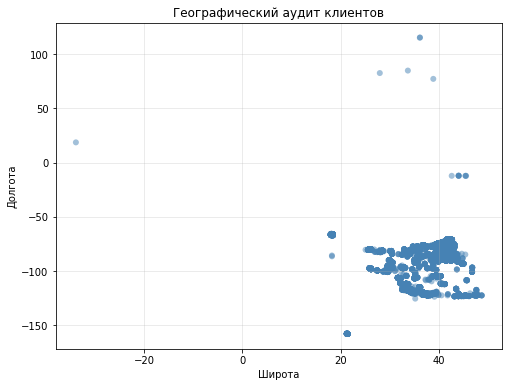

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(df_customers['customer_lat'], df_customers['customer_lon'], alpha=0.5, c='steelblue', edgecolor='none')
plt.grid(True, alpha=0.3)
plt.title('Географический аудит клиентов')
plt.xlabel('Широта')
plt.ylabel('Долгота')
plt.show()

In [13]:
mask = (df_customers['customer_lon'] >= -125) & (df_customers['customer_lon'] <= -20)
df_customers = df_customers[mask]

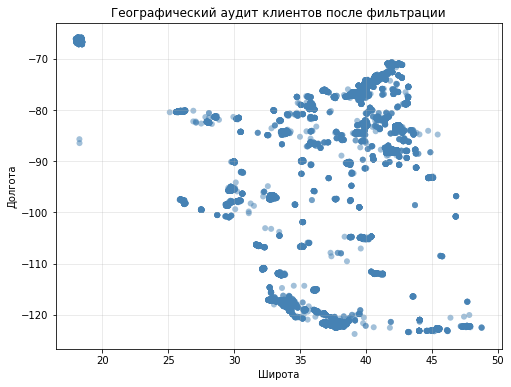

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df_customers['customer_lat'], df_customers['customer_lon'], alpha=0.5, c='steelblue', edgecolor='none')
plt.grid(True, alpha=0.3)
plt.title('Географический аудит клиентов после фильтрации')
plt.xlabel('Широта')
plt.ylabel('Долгота')
plt.show()

In [15]:
id_check = df_orders[~df_orders['customer_id'].isin(df_customers['customer_id'])].index
print('Заказы без профилей после фильтрации : ', len(id_check))

df_orders = df_orders.drop(id_check)
id_check_after = df_orders[~df_orders['customer_id'].isin(df_customers['customer_id'])]
print('Проверка наличия заказов без профиля : ',len(id_check_after))

Заказы без профилей после фильтрации :  1430
Проверка наличия заказов без профиля :  0


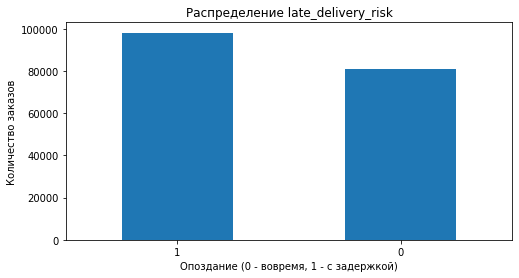

In [17]:
plt.figure(figsize=(8, 4))
df_orders['late_delivery_risk'].value_counts().plot(kind='bar')
plt.title('Распределение late_delivery_risk')
plt.xlabel('Опоздание (0 - вовремя, 1 - с задержкой)')
plt.ylabel('Количество заказов')
plt.xticks(rotation=0)
plt.show()

interval columns not set, guessing: ['late_delivery_risk', 'item_price', 'order_month', 'order_weekday', 'order_hour']


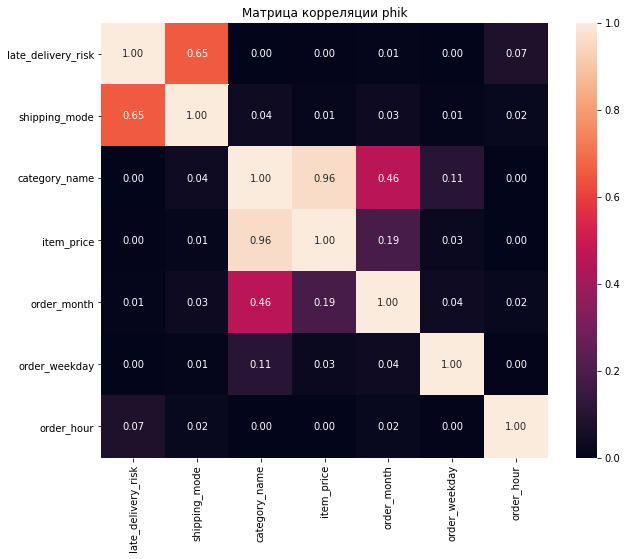

In [18]:
phik_matrix = df_orders[['late_delivery_risk','shipping_mode','category_name','item_price','order_month','order_weekday','order_hour']].phik_matrix()

plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, fmt='.2f')
plt.title('Матрица корреляции phik')
plt.show()

>Дисбаланса в целевой переменной нет  
1 - 55%  
0 - 45%  
После графического аудита были удалены аномальные данные по ТЗ в кординатах, а также были удалены заказы без пользователей  
На тепловой карте видна корреляция с shipping_mode - 0.65


##  Разделение на выборки


Разделите датафрейм с заказами на выборки. В этом проекте вам предстоит  использовать «классическое» разделение на три выборки: обучающую, валидационную и тестовую. Использовать для этого нужно не `train_test_split`, а `GroupShuffleSplit`. Он делит данные так, чтобы группы, то есть клиенты, не пересекались.

Ниже приведён пример того, как отделить часть данных для обучения, используя `customer_id` как ключ для группировки.

```python
from sklearn.model_selection import GroupShuffleSplit

# 1. Выбираем колонку, по которой будем группировать (наши "группы")
groups = df_orders['customer_id']

# 2. Инициализируем сплиттер (например, отделим 20% клиентов для теста)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

# 3. Получаем индексы для разделения
# Метод split возвращает генератор, поэтому используем next()
train_idx, test_idx = next(gss.split(df_orders, groups=groups))

# 4. Формируем выборки
df_train = df_orders.iloc[train_idx]
df_test = df_orders.iloc[test_idx]

```

1. Разделите данные из датафрейма с заказами  на три выборки  в соотношении 60:20:20.

2. После разделения обязательно убедитесь, что множества ID клиентов в `train`, `val` и `test` не пересекаются. Если один и тот же клиент попал в разные выборки, то разделение выполнено неверно.


In [19]:
groups = df_orders['customer_id']

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.4, random_state=RANDOM_STATE)
train_idx, temp_idx = next(gss1.split(df_orders, groups=groups))

df_train = df_orders.iloc[train_idx]
df_temp = df_orders.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE)
val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp['customer_id']))

df_val = df_temp.iloc[val_idx]
df_test = df_temp.iloc[test_idx]

train_ids = set(df_train['customer_id'])
val_ids = set(df_val['customer_id'])
test_ids = set(df_test['customer_id'])

print(f'Train: {len(df_train)} заказов, {len(train_ids)} клиентов')
print(f'Val:   {len(df_val)} заказов, {len(val_ids)} клиентов')
print(f'Test:  {len(df_test)} заказов, {len(test_ids)} клиентов')
print()
print(f'Train ∩ Val:  {len(train_ids & val_ids)}')
print(f'Train ∩ Test: {len(train_ids & test_ids)}')
print(f'Val ∩ Test:   {len(val_ids & test_ids)}')

Train: 107721 заказов, 12297 клиентов
Val:   35355 заказов, 4099 клиентов
Test:  36013 заказов, 4100 клиентов

Train ∩ Val:  0
Train ∩ Test: 0
Val ∩ Test:   0


>Разделил данные на 3 дата сета 60:20:20


## Обучение базовой модели


Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Вам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберите нужные признаки — используйте колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Обучите логистическую регрессию и `CatBoostClassifier` и оцените их качество.

3. Оцените качество обеих моделей на валидационной выборке.

Напоминаем, что на этапе построения базовой модели глубокий подбор гиперпараметров необязателен.

**Дополнительное задание.** Если вы чувствуете в себе силы, вы можете попробовать базовую оптимизацию, но помните: главная прибавка к качеству ожидается от новых признаков, которые вы создадите в следующих разделах.


In [32]:
features = ['shipping_mode', 'category_name', 'item_price', 'order_hour', 'order_weekday', 'order_month']
cat_features = ['shipping_mode', 'category_name']

X_train = df_train[features]
y_train = df_train['late_delivery_risk']
X_val = df_val[features]
y_val = df_val['late_delivery_risk']

X_train_ohe = pd.get_dummies(X_train, columns=cat_features, drop_first=True)
X_val_ohe = pd.get_dummies(X_val, columns=cat_features, drop_first=True)

X_val_ohe = X_val_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ohe)
X_val_scaled = scaler.transform(X_val_ohe)

lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred_proba = lr.predict_proba(X_val_scaled)[:, 1]
lr_roc = roc_auc_score(y_val, lr_pred_proba)
print(f'Logistic Regression ROC-AUC: {lr_roc:.4f}')

Logistic Regression ROC-AUC: 0.7344


In [33]:
catb = CatBoostClassifier(iterations=1000, random_seed=RANDOM_STATE, verbose=200)
catb.fit(X_train, y_train, cat_features=cat_features)
catb_pred_proba = catb.predict_proba(X_val)[:, 1]
catb_roc = roc_auc_score(y_val, catb_pred_proba)
print(f'CatBoost ROC-AUC: {catb_roc:.4f}')

Learning rate set to 0.075985
0:	learn: 0.6718469	total: 73.2ms	remaining: 1m 13s
200:	learn: 0.5319335	total: 16.2s	remaining: 1m 4s
400:	learn: 0.5275951	total: 33.7s	remaining: 50.4s
600:	learn: 0.5242667	total: 51.5s	remaining: 34.2s
800:	learn: 0.5215073	total: 1m 9s	remaining: 17.2s
999:	learn: 0.5188855	total: 1m 26s	remaining: 0us
CatBoost ROC-AUC: 0.7572


>Обучил две модели  
Logistic Regression - ROC-AUC: 0.7344  
CatBoost -  ROC-AUC: 0.7572


##  Кластеризация по признакам, связанным с местоположением


На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.

**Ваши действия:**

1. Проведите корректную подготовку признаков.
2. Продумайте защиту от утечки данных.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Постройте график с полученными кластерами и отметьте центроиды.


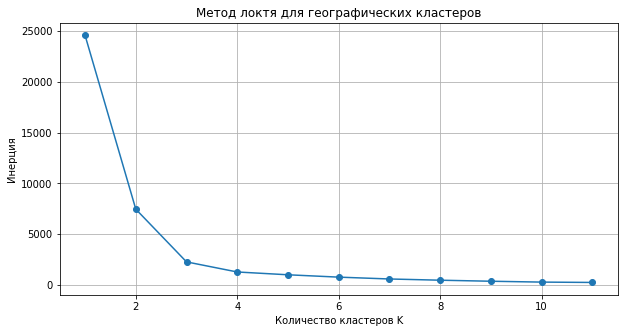

In [21]:
coords = df_customers[['customer_lat', 'customer_lon']]

train_customer_ids = df_train['customer_id'].unique()
train_customers_mask = df_customers['customer_id'].isin(train_customer_ids)

scaler_geo = StandardScaler()
scaler_geo.fit(coords[train_customers_mask])
coords_scaled = scaler_geo.transform(coords)

inertia = []
K_range = range(1, 12)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(coords_scaled[train_customers_mask])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Метод локтя для географических кластеров')
plt.xlabel('Количество кластеров K')
plt.ylabel('Инерция')
plt.grid(True)
plt.show()

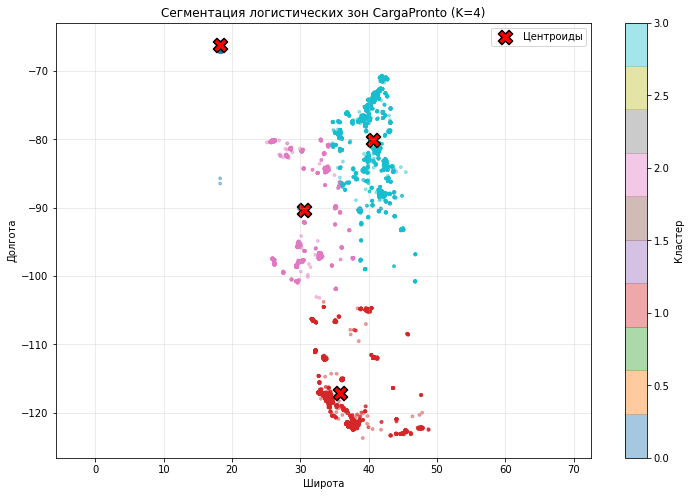

In [22]:
K_GEO = 4
kmeans_geo = KMeans(n_clusters=K_GEO, random_state=RANDOM_STATE, n_init=10)
kmeans_geo.fit(coords_scaled[train_customers_mask])

df_customers['geo_cluster'] = kmeans_geo.predict(coords_scaled)

centroids_scaled = kmeans_geo.cluster_centers_
centroids = scaler_geo.inverse_transform(centroids_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_customers['customer_lat'], 
    df_customers['customer_lon'],
    c=df_customers['geo_cluster'], 
    cmap='tab10', 
    alpha=0.4, 
    s=8
)
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    marker='X', 
    c='red', 
    s=200, 
    edgecolor='black', 
    linewidth=1.5, 
    label='Центроиды'
)
plt.colorbar(scatter, label='Кластер')
plt.legend()
plt.title(f'Сегментация логистических зон CargaPronto (K={K_GEO})')
plt.xlabel('Широта')
plt.ylabel('Долгота')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

>Кластеризация по признакам  
Методом локтя нашёл оптимальное число кластеров - 4  
Постоил график с центрами


##  Кластеризация по признакам профилей клиентов


1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.


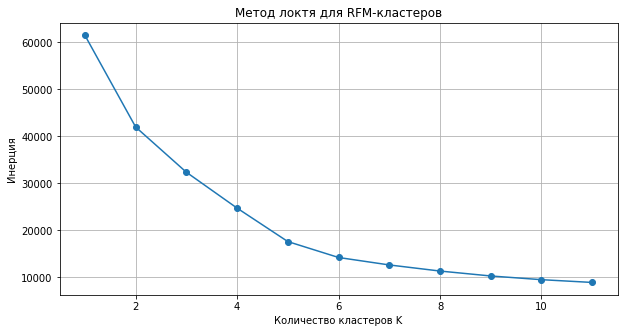

In [23]:
rfm_features = ['recency', 'total_orders', 'total_sales', 'avg_discount', 'return_rate']

train_customer_ids = df_train['customer_id'].unique()
train_customers_mask = df_customers['customer_id'].isin(train_customer_ids)

scaler_rfm = StandardScaler()
scaler_rfm.fit(df_customers.loc[train_customers_mask, rfm_features])
rfm_scaled = scaler_rfm.transform(df_customers[rfm_features])

inertia = []
K_range = range(1, 12)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(rfm_scaled[train_customers_mask])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Метод локтя для RFM-кластеров')
plt.xlabel('Количество кластеров K')
plt.ylabel('Инерция')
plt.grid(True)
plt.show()

In [24]:
K_RFM = 6
kmeans_rfm = KMeans(n_clusters=K_RFM, random_state=RANDOM_STATE, n_init=10)
kmeans_rfm.fit(rfm_scaled[train_customers_mask])

df_customers['beh_cluster'] = kmeans_rfm.predict(rfm_scaled)

cluster_stats = df_customers.groupby('beh_cluster')[rfm_features].mean()
print(cluster_stats)

                recency  total_orders  total_sales  avg_discount  return_rate
beh_cluster                                                                  
0            240.071918      7.311644  4185.609412      0.100905     0.044060
1             71.095964      1.049163   315.825774      0.048120     0.000132
2            155.935685      1.350622   502.788758      0.101516     0.926294
3            263.572061      4.266273  2195.381014      0.102337     0.038100
4             72.045225      1.055068   276.827617      0.168783     0.000340
5            645.213473      2.723535  1400.799657      0.100279     0.024645


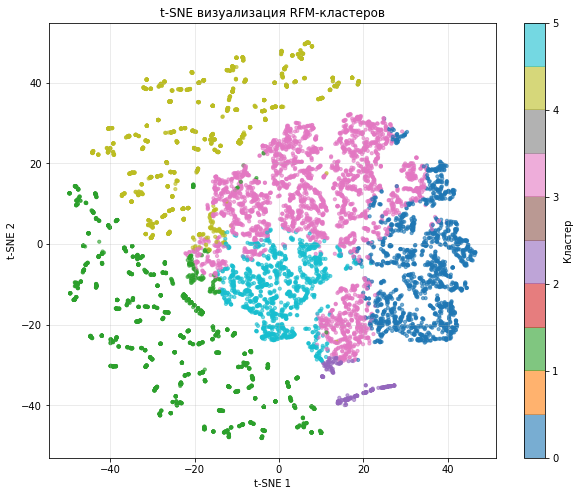

In [25]:
sample_size = 10000
df_sample = df_customers.sample(n=sample_size, random_state=RANDOM_STATE)

rfm_sample_scaled = scaler_rfm.transform(df_sample[rfm_features])

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=500, init='pca')
tsne_result = tsne.fit_transform(rfm_sample_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    c=df_sample['beh_cluster'],
    cmap='tab10',
    alpha=0.6,
    s=10
)
plt.colorbar(scatter, label='Кластер')
plt.title('t-SNE визуализация RFM-кластеров')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.show()

##  Обучение модели на новых признаках


1. Добавьте результаты кластеризаций в данные для обучения моделей.
2. Обучите финальные версии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитайте итоговые значения метрики ROC−AUC на валидационной выборке.


In [26]:

cluster_cols = df_customers[['customer_id', 'geo_cluster', 'beh_cluster']]

df_train = df_train.merge(cluster_cols, on='customer_id', how='left')
df_val = df_val.merge(cluster_cols, on='customer_id', how='left')
df_test = df_test.merge(cluster_cols, on='customer_id', how='left')

print('Пропуски в train:', df_train[['geo_cluster', 'beh_cluster']].isnull().sum().sum())
print('Пропуски в val:', df_val[['geo_cluster', 'beh_cluster']].isnull().sum().sum())
print('Пропуски в test:', df_test[['geo_cluster', 'beh_cluster']].isnull().sum().sum())

Пропуски в train: 0
Пропуски в val: 0
Пропуски в test: 0


>Добавил новые епризнаки и проверил на пропуски после объединения


In [27]:
features_new = ['shipping_mode', 'category_name', 'item_price', 
                'order_hour', 'order_weekday', 'order_month',
                'geo_cluster', 'beh_cluster']
cat_features_new = ['shipping_mode', 'category_name']

X_train_new = df_train[features_new]
y_train_new = df_train['late_delivery_risk']
X_val_new = df_val[features_new]
y_val_new = df_val['late_delivery_risk']

X_train_ohe_new = pd.get_dummies(X_train_new, columns=cat_features_new, drop_first=True)
X_val_ohe_new = pd.get_dummies(X_val_new, columns=cat_features_new, drop_first=True)
X_val_ohe_new = X_val_ohe_new.reindex(columns=X_train_ohe_new.columns, fill_value=0)
scaler_new = StandardScaler()
X_train_scaled_new = scaler_new.fit_transform(X_train_ohe_new)
X_val_scaled_new = scaler_new.transform(X_val_ohe_new)

lr_new = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_new.fit(X_train_scaled_new, y_train_new)
lr_new_pred = lr_new.predict_proba(X_val_scaled_new)[:, 1]
lr_new_roc = roc_auc_score(y_val_new, lr_new_pred)
print(f'Logistic Regression (с кластерами) ROC-AUC: {lr_new_roc:.4f}')

Logistic Regression (с кластерами) ROC-AUC: 0.7345
Learning rate set to 0.075985
0:	learn: 0.6635144	total: 93.9ms	remaining: 1m 33s
200:	learn: 0.5237416	total: 17.4s	remaining: 1m 9s
400:	learn: 0.5168127	total: 36.1s	remaining: 54s
600:	learn: 0.5115647	total: 55.1s	remaining: 36.6s
800:	learn: 0.5072846	total: 1m 13s	remaining: 18.1s
999:	learn: 0.5037605	total: 1m 30s	remaining: 0us
CatBoost (с кластерами) ROC-AUC: 0.7635


In [ ]:
catb_new = CatBoostClassifier(iterations=1000, random_seed=RANDOM_STATE, verbose=200)
catb_new.fit(X_train_new, y_train_new, cat_features=cat_features_new)
catb_new_pred = catb_new.predict_proba(X_val_new)[:, 1]
catb_new_roc = roc_auc_score(y_val_new, catb_new_pred)
print(f'CatBoost (с кластерами) ROC-AUC: {catb_new_roc:.4f}')

>После обучения с новыми признаками получились следующие результаты

Logistic Regression базовая:     0.7344
Logistic Regression с кластерами: 0.7345
CatBoost базовый:                0.7572
CatBoost с кластерами:           0.7635

>После добавления признаков метрики улучшелись.   
CatBoost показал себя лучше по этому для финальных тестот буду использовать его


## Дополнительное задание — подбор лучшего количества кластеров


Рассмотрите количество кластеров как гиперпараметр всей системы и найти ту «степень детализации», которая даст максимальный прирост ROC-AUC.

Вы можете взять значения из списка или выбрать свои:

```python
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]
```


In [ ]:
-

## Тестирование лучшей модели


На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?


In [29]:

X_test_new = df_test[features_new]
y_test = df_test['late_delivery_risk']

test_pred_proba = catb_new.predict_proba(X_test_new)[:, 1]
test_roc = roc_auc_score(y_test, test_pred_proba)
print(f'ROC-AUC на тесте: {test_roc:.4f}')
print(f'Целевой показатель: 0.75')

ROC-AUC на тесте: 0.7601
Целевой показатель: 0.75


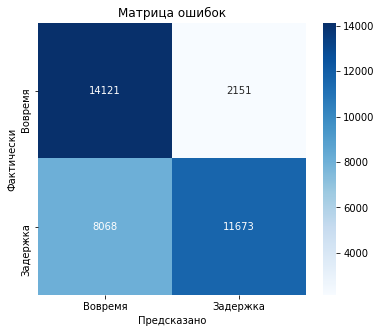

              precision    recall  f1-score   support

     Вовремя       0.64      0.87      0.73     16272
    Задержка       0.84      0.59      0.70     19741

    accuracy                           0.72     36013
   macro avg       0.74      0.73      0.71     36013
weighted avg       0.75      0.72      0.71     36013



In [30]:

test_pred = catb_new.predict(X_test_new)
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Вовремя', 'Задержка'],
            yticklabels=['Вовремя', 'Задержка'])
plt.title('Матрица ошибок')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.show()

print(classification_report(y_test, test_pred, target_names=['Вовремя', 'Задержка']))

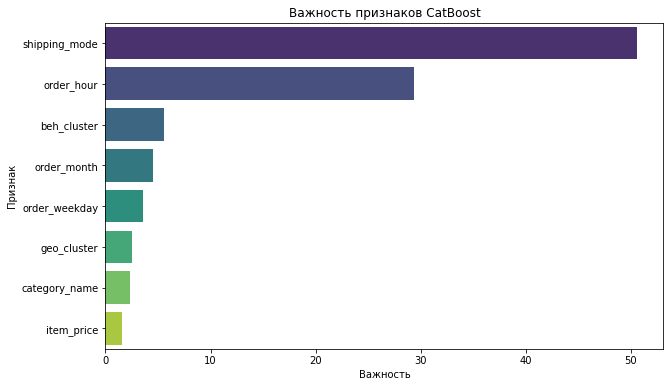

         feature  importance
0  shipping_mode   50.584259
3     order_hour   29.323795
7    beh_cluster    5.576365
5    order_month    4.545431
4  order_weekday    3.551601
6    geo_cluster    2.489627
1  category_name    2.362903
2     item_price    1.566019


In [31]:

feature_importance = pd.DataFrame({
    'feature': features_new,
    'importance': catb_new.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Важность признаков CatBoost')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.show()

print(feature_importance)

>**Краткие выводы:**  
**ROC-AUC = 0.76** — целевой показатель 0.75 достигнут. Модель работает лучше случайного угадывания и пригодна для использования.  
**Матрица ошибок:**  
-Модель хорошо распознаёт вовремя доставленные заказы (recall 87%)  
-Хуже выявляет задержки (recall 59%) — пропускает почти 41% реальных опозданий  
-Когда модель предсказывает задержку, в 84% случаев она права (precision 84%)  
**Важность признаков:**  
-`shipping_mode` (50.6%) и `order_hour` (29.3%) — ключевые факторы  
-`beh_cluster` (5.6%) — третий по значимости, поведенческий сегмент клиента важен  
-`geo_cluster` (2.5%) — на шестом месте, географическая зона влияет, но слабее  
-`item_price` и `category_name` — наименее значимы  
**Кластеры полезны:** `beh_cluster` вошёл в топ-3 признаков, `geo_cluster` тоже даёт вклад. Гипотеза подтвердилась — профиль клиента помогает предсказывать задержки.  
**Основной вывод:** способ доставки и время заказа — главные рычаги управления рисками. Сегментация клиентов добавляет точности, но не перевешивает логистические факторы.


##  Выводы и рекомендации


Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargaPronto может использовать вашу модель в реальных операциях.


**Выводы и рекомендации**

---

**Результаты моделирования**

ROC-AUC на тесте — 0.76, целевой показатель 0.75 достигнут. CatBoost с кластерами улучшил базовый результат (0.7572 → 0.7635). Модель готова к внедрению.

---

**Эффективность сегментации**

Гипотеза подтвердилась частично. Поведенческий кластер вошёл в топ-3 признаков (5.6%), географический — на шестом месте (2.5%). Поведение клиента важнее географии. Кластеризация выделила шесть сегментов, включая проблемных клиентов с 93% возвратов и спящих клиентов с давностью заказов более 600 дней.

---

**Технический инсайт**

Оптимальное количество кластеров: geo — 4, rfm — 6. Слишком большое K дробит группы на мелкие, модель переобучается и качество падает.

---

**Бизнес-рекомендации**

1. Способ доставки — главный рычаг. При высоком риске задержки автоматически повышать класс доставки, если доплата ниже штрафа по SLA.
2. В часы пик (order_hour — 29% важности) назначать повышенный приоритет сборки.
3. Для клиентов с высокой долей возвратов подтверждать заказ до отправки.
4. Для спящих клиентов запрашивать подтверждение адреса.
5. Внедрить систему предупреждений: при вероятности задержки > 70% оповещать диспетчера и предлагать смену приоритета или способа доставки.
